In [1]:
import pandas as pd
import numpy as np

In [2]:
patient_priority_data = pd.read_csv('/content/patient_priority.csv')
patient_data = pd.read_csv("/content/patients.csv")

In [3]:
df_patient_priority = pd.DataFrame(patient_priority_data)
df_patient_priority.head()

,Unnamed: 0,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
0,0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,Urban,never smoked,yellow
1,1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
2,2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,Urban,never smoked,yellow
3,3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
4,4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,Urban,never smoked,yellow


In [4]:
df_patient = pd.DataFrame(patient_data)
df_patient.head()

,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61
1,PAT-f0644084,Shannon Walker,6,2025-12-13,2025-12-14,surgery,83
2,PAT-ac6162e4,Julia Torres,24,2025-06-29,2025-07-05,general_medicine,83
3,PAT-3dda2bb5,Crystal Johnson,32,2025-10-12,2025-10-23,emergency,81
4,PAT-08591375,Garrett Lin,25,2025-02-18,2025-02-25,ICU,76


In [5]:
df_patient_priority.drop(['Unnamed: 0'], axis = 1,inplace=True)
df_patient_priority.head()

,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,triage
0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,Urban,never smoked,yellow
1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,Urban,never smoked,yellow
3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,Urban,never smoked,orange
4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,Urban,never smoked,yellow


In [6]:
df_patient_priority.fillna(df_patient_priority.mode().iloc[0], inplace=True)

In [7]:
# print(df_patient_priority.info())
# print(f"Duplicates: {df_patient_priority.duplicated().sum()}")
print(df_patient_priority['triage'].value_counts())

triage
yellow    6047
green      440
orange     346
red        129
Name: count, dtype: int64


In [8]:
dict_ward = {"Ward Type" : []}
df_Ward = pd.DataFrame(dict_ward)
df_Ward

for i in range((df_patient_priority.shape)[0]):
  if( df_patient_priority.loc[i, 'triage'] == 'red' or
     (df_patient_priority.loc[i, 'heart_disease'] == 1 and df_patient_priority.loc[i, 'chest pain type'] == 4 ) or
      (df_patient_priority.loc[i, 'heart_disease'] == 1 and df_patient_priority.loc[i, 'exercise angina'] == 1)):
      df_Ward.loc[i, 'Ward Type'] = 'ICU'

  elif( df_patient_priority.loc[i, 'heart_disease'] == 1 or
     df_patient_priority.loc[i, 'chest pain type'] >= 3  or
      df_patient_priority.loc[i, 'exercise angina'] == 1):
      df_Ward.loc[i, 'Ward Type'] = 'Cardiac Ward'

  elif( df_patient_priority.loc[i, 'hypertension'] == 1 or
     df_patient_priority.loc[i, 'blood pressure'] > 140  or
      df_patient_priority.loc[i, 'cholesterol'] > 240):
      df_Ward.loc[i, 'Ward Type'] = 'Cardiology Ward'

  elif( df_patient_priority.loc[i, 'plasma glucose'] > 140 or
     df_patient_priority.loc[i, 'insulin'] > 120  or
      df_patient_priority.loc[i, 'bmi'] > 35):
      df_Ward.loc[i, 'Ward Type'] = 'Endocrinology Ward'

  elif(df_patient_priority.loc[i, 'triage'] == 'orange'or
       df_patient_priority.loc[i, 'chest pain type'] == 2):
    df_Ward.loc[i, 'Ward Type'] = 'Emergency Ward'

  else:
    df_Ward.loc[i, 'Ward Type'] = 'General Ward'



df_Ward.loc[0:40]

/tmp/ipykernel_607/72000068.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Cardiology Ward' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_Ward.loc[i, 'Ward Type'] = 'Cardiology Ward'


,Ward Type
0,Cardiology Ward
1,Cardiac Ward
2,Cardiology Ward
3,Cardiac Ward
4,Cardiac Ward
5,Cardiac Ward
6,Emergency Ward
7,Emergency Ward
8,Cardiac Ward
9,Cardiology Ward


In [9]:
print(df_Ward['Ward Type'].value_counts())
print("\nPercentages:")
print(df_Ward['Ward Type'].value_counts(normalize=True) * 100)

Ward Type
General Ward          2553
Endocrinology Ward    2469
Cardiac Ward          1093
Cardiology Ward        563
Emergency Ward         155
ICU                    129
Name: count, dtype: int64

Percentages:
Ward Type
General Ward          36.670497
Endocrinology Ward    35.463947
Cardiac Ward          15.699512
Cardiology Ward        8.086757
Emergency Ward         2.226372
ICU                    1.852916
Name: proportion, dtype: float64


In [10]:
print(df_Ward['Ward Type'].value_counts())

Ward Type
General Ward          2553
Endocrinology Ward    2469
Cardiac Ward          1093
Cardiology Ward        563
Emergency Ward         155
ICU                    129
Name: count, dtype: int64


In [11]:
# remove unnecessary columns 'Residence_type', 'smoking_status', 'diabetes_pedigree'
# add ward coluumm

df_patient_priority.drop(columns = ['triage'], axis = 0, inplace = True)
df_patient_priority['Ward Type'] = df_Ward['Ward Type']
df_patient_priority.head()

,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Residence_type,smoking_status,Ward Type
0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.0,43.0,92.0,19.0,0.467386,0.0,0.0,Urban,never smoked,Cardiology Ward
1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.0,47.0,90.0,18.0,0.467386,0.0,0.0,Urban,never smoked,Cardiac Ward
2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.0,53.0,102.0,23.0,0.467386,0.0,0.0,Urban,never smoked,Cardiology Ward
3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.0,51.0,118.0,18.0,0.467386,0.0,0.0,Urban,never smoked,Cardiac Ward
4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.0,90.0,83.0,21.0,0.467386,0.0,0.0,Urban,never smoked,Cardiac Ward


In [12]:
from sklearn.preprocessing import LabelEncoder

df_patient_priority['smoking_status_encoded'] = LabelEncoder().fit_transform(df_patient_priority['smoking_status'])
df_patient_priority['Residence_type_encoded'] = LabelEncoder().fit_transform(df_patient_priority['Residence_type'])

df_patient_priority_final = df_patient_priority.drop(columns = ['smoking_status', 'Residence_type'], axis = 1)

In [13]:
df_patient_priority_final

,age,gender,chest pain type,blood pressure,cholesterol,max heart rate,exercise angina,plasma glucose,skin_thickness,insulin,bmi,diabetes_pedigree,hypertension,heart_disease,Ward Type,smoking_status_encoded,Residence_type_encoded
0,40.0,1.0,2.0,140.0,294.0,172.0,0.0,108.00,43.0,92.0,19.0,0.467386,0.0,0.0,Cardiology Ward,2,1
1,49.0,0.0,3.0,160.0,180.0,156.0,0.0,75.00,47.0,90.0,18.0,0.467386,0.0,0.0,Cardiac Ward,2,1
2,37.0,1.0,2.0,130.0,294.0,156.0,0.0,98.00,53.0,102.0,23.0,0.467386,0.0,0.0,Cardiology Ward,2,1
3,48.0,0.0,4.0,138.0,214.0,156.0,1.0,72.00,51.0,118.0,18.0,0.467386,0.0,0.0,Cardiac Ward,2,1
4,54.0,1.0,3.0,150.0,195.0,156.0,0.0,108.00,90.0,83.0,21.0,0.467386,0.0,0.0,Cardiac Ward,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6957,80.0,0.0,0.0,111.0,153.0,166.0,0.0,83.75,31.0,108.0,18.6,0.467386,1.0,0.0,Cardiology Ward,2,1
6958,81.0,0.0,0.0,123.0,157.0,160.0,0.0,125.20,23.0,89.0,40.0,0.467386,0.0,0.0,Endocrinology Ward,2,1
6959,81.0,0.0,0.0,127.0,185.0,141.0,0.0,82.99,41.0,95.0,30.6,0.467386,0.0,0.0,General Ward,2,0
6960,51.0,1.0,0.0,123.0,161.0,162.0,0.0,166.29,34.0,93.0,25.6,0.467386,0.0,0.0,Endocrinology Ward,1,0


In [14]:
from sklearn.model_selection import train_test_split

X = df_patient_priority_final.drop(columns = ['Ward Type'], axis=1)
Y = df_patient_priority_final['Ward Type']

x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state = 42, test_size = 0.2, stratify = Y)

y_train_encoded = LabelEncoder().fit_transform(y_train)
y_test_encoded = LabelEncoder().fit_transform(y_test)

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

n_estimator = 100
pipe1 = Pipeline([('scaler', StandardScaler()), ('Forest_classification', RandomForestClassifier(n_estimators=n_estimator, class_weight = 'balanced' ,random_state = 42))])
xgb = XGBClassifier(n_estimators=n_estimator, tree_method = 'hist',  eval_metric = 'mlogloss' ,random_state = 42)

print("Training Random Forest classifier .......")
pipe1.fit(x_train, y_train)
print("Training XGBoost classifier ..........")
xgb.fit(x_train, y_train_encoded)

yhat1 = pipe1.predict(x_test)
yhat2 = xgb.predict(x_test)
print("Models Trained :)")

Training Random Forest classifier .......
Training XGBoost classifier ..........
Models Trained :)


In [16]:
from sklearn.metrics import accuracy_score

print(f"Accuracy of Random Forest Classifier : {accuracy_score(y_test, yhat1)}")
print(f"Accuracy of XGB Classifier : {accuracy_score(y_test_encoded, yhat2)}")

Accuracy of Random Forest Classifier : 0.994256999282125
Accuracy of XGB Classifier : 0.9956927494615937


In [17]:
# Check this carefully:
print("y_test type:", type(y_test))
print("y_test_encoded type:", type(y_test_encoded))

# For Random Forest:
print(f"\nRF - y_test sample: {y_test[:5].values}")
print(f"RF - yhat1 sample: {yhat1[:5]}")

# For XGBoost:
print(f"\nXGB - y_test_encoded sample: {y_test_encoded[:5]}")
print(f"XGB - yhat2 sample: {yhat2[:5]}")

y_test type: <class 'pandas.core.series.Series'>
y_test_encoded type: <class 'numpy.ndarray'>

RF - y_test sample: ['Emergency Ward' 'Endocrinology Ward' 'General Ward' 'Cardiac Ward'
 'Endocrinology Ward']
RF - yhat1 sample: ['Emergency Ward' 'Endocrinology Ward' 'General Ward' 'Cardiac Ward'
 'Endocrinology Ward']

XGB - y_test_encoded sample: [2 3 4 0 3]
XGB - yhat2 sample: [2 3 4 0 3]


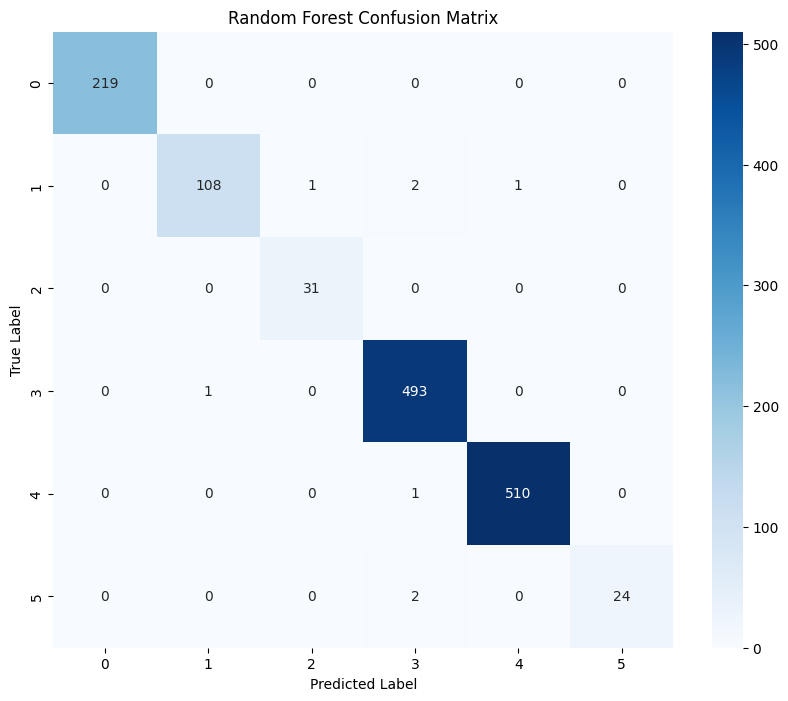


Random Forest Classification Report:
                    precision    recall  f1-score   support

      Cardiac Ward       1.00      1.00      1.00       219
   Cardiology Ward       0.99      0.96      0.98       112
    Emergency Ward       0.97      1.00      0.98        31
Endocrinology Ward       0.99      1.00      0.99       494
      General Ward       1.00      1.00      1.00       511
               ICU       1.00      0.92      0.96        26

          accuracy                           0.99      1393
         macro avg       0.99      0.98      0.99      1393
      weighted avg       0.99      0.99      0.99      1393



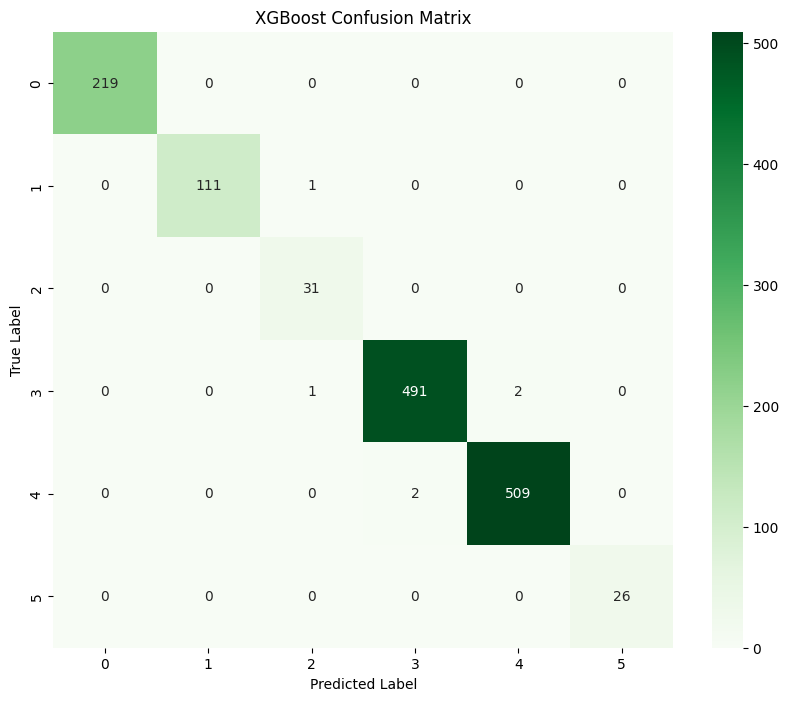


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       1.00      0.99      1.00       112
           2       0.94      1.00      0.97        31
           3       1.00      0.99      0.99       494
           4       1.00      1.00      1.00       511
           5       1.00      1.00      1.00        26

    accuracy                           1.00      1393
   macro avg       0.99      1.00      0.99      1393
weighted avg       1.00      1.00      1.00      1393



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest confusion matrix
cm1 = confusion_matrix(y_test, yhat1)
plt.figure(figsize=(10,8))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, yhat1))

# XGBoost confusion matrix
cm2 = confusion_matrix(y_test_encoded, yhat2)
plt.figure(figsize=(10,8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print("\nXGBoost Classification Report:")
print(classification_report(y_test_encoded, yhat2))

In [19]:
# 1. Verify no data leakage
print("Features used:")
print(x_train.columns.tolist())
print("\n'triage' in features?", 'triage' in x_train.columns)
print("'ward' in features?", 'ward' in x_train.columns)

# 2. Check train/test split
print(f"\nTrain size: {len(x_train)}")
print(f"Test size: {len(x_test)}")
print(f"Total: {len(x_train) + len(x_test)}")

# 3. Verify stratification worked
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

# 4. Check for perfect predictions on minority classes
print("\nPer-class accuracy:")
for ward in y_test.unique():
    mask = y_test == ward
    acc = accuracy_score(y_test[mask], yhat1[mask])
    print(f"{ward}: {acc:.4f} ({mask.sum()} samples)")

Features used:
['age', 'gender', 'chest pain type', 'blood pressure', 'cholesterol', 'max heart rate', 'exercise angina', 'plasma glucose', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'hypertension', 'heart_disease', 'smoking_status_encoded', 'Residence_type_encoded']

'triage' in features? False
'ward' in features? False

Train size: 5569
Test size: 1393
Total: 6962

Train distribution:
Ward Type
General Ward          0.366673
Endocrinology Ward    0.354642
Cardiac Ward          0.156940
Cardiology Ward       0.080984
Emergency Ward        0.022266
ICU                   0.018495
Name: proportion, dtype: float64

Test distribution:
Ward Type
General Ward          0.366834
Endocrinology Ward    0.354630
Cardiac Ward          0.157215
Cardiology Ward       0.080402
Emergency Ward        0.022254
ICU                   0.018665
Name: proportion, dtype: float64

Per-class accuracy:
Emergency Ward: 1.0000 (31 samples)
Endocrinology Ward: 0.9980 (494 samples)
General Ward: 0.9980

In [ ]:
import joblib
import os

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(pipe1, 'models/saved/random_forest_model.pkl')
joblib.dump(xgb, 'models/saved/xgboost_model.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

print("✅ Models saved to models/ directory")

✅ Models saved to models/ directory


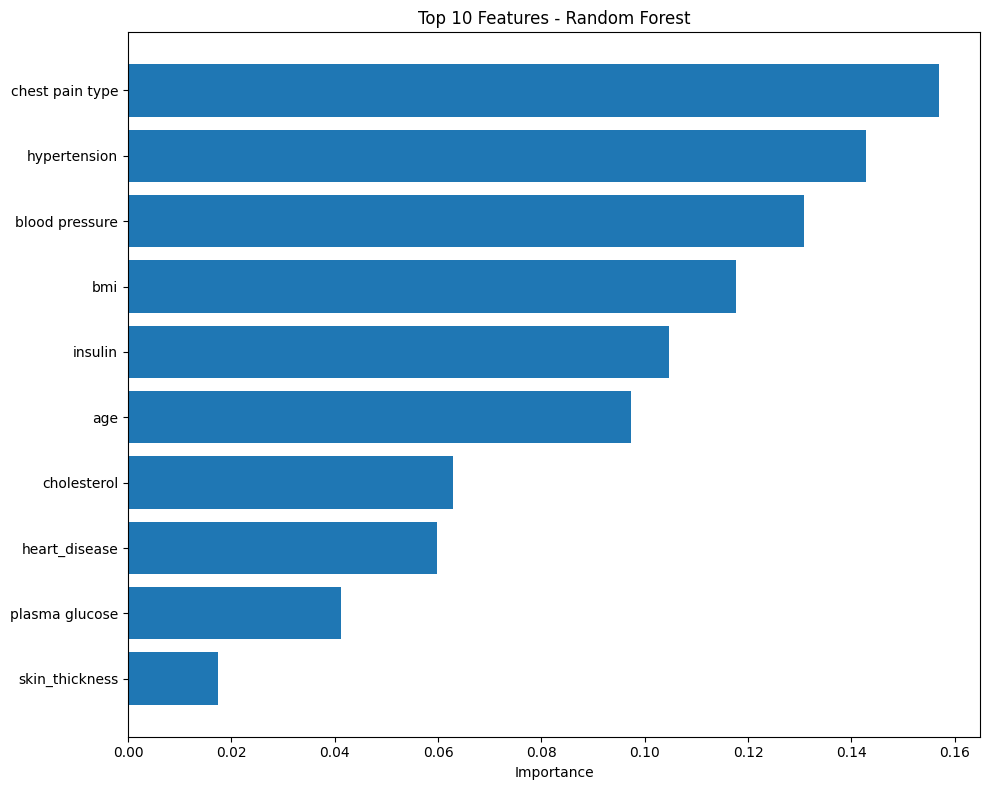

Top 10 Important Features (Random Forest):
            feature  importance
2   chest pain type    0.157040
12     hypertension    0.142830
3    blood pressure    0.130888
10              bmi    0.117605
9           insulin    0.104640
0               age    0.097299
4       cholesterol    0.062810
13    heart_disease    0.059750
7    plasma glucose    0.041151
8    skin_thickness    0.017501


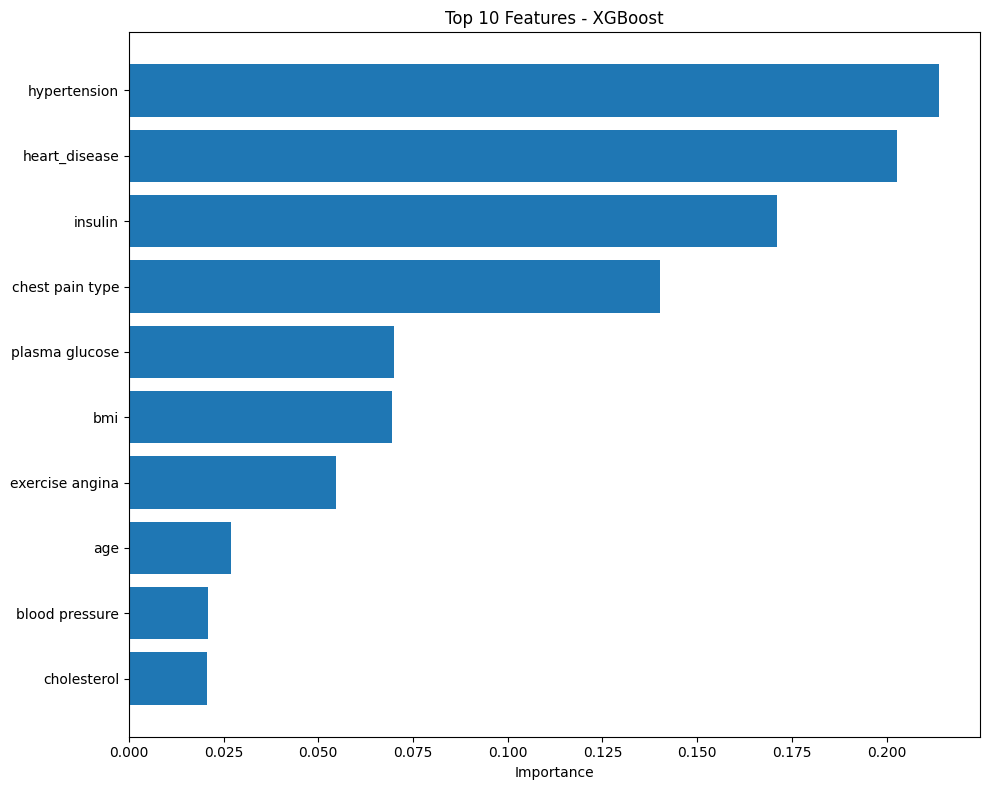


Top 10 Important Features (XGBoost):
            feature  importance
12     hypertension    0.213977
13    heart_disease    0.202716
9           insulin    0.171100
2   chest pain type    0.140264
7    plasma glucose    0.069995
10              bmi    0.069543
6   exercise angina    0.054674
0               age    0.026918
3    blood pressure    0.020908
4       cholesterol    0.020667


In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Random Forest Feature Importance
# Use the ACTUAL name from your pipeline: 'Forest_classification'
rf_model = pipe1.named_steps['Forest_classification']

feature_importance_rf = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_rf['feature'][:10], feature_importance_rf['importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 Important Features (Random Forest):")
print(feature_importance_rf.head(10))

# XGBoost Feature Importance
feature_importance_xgb = pd.DataFrame({
    'feature': x_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_xgb['feature'][:10], feature_importance_xgb['importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Features - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Important Features (XGBoost):")
print(feature_importance_xgb.head(10))

In [23]:
# Create a comprehensive summary
summary = f"""
MODEL PERFORMANCE SUMMARY
========================

Dataset:
- Total samples: {len(df_patient_priority_final)}
- Training samples: {len(x_train)}
- Testing samples: {len(x_test)}
- Features: {len(x_train.columns)}
- Classes: {len(y_train.unique())}

Class Distribution:
{y_train.value_counts()}

Model Results:
--------------
Random Forest:
- Accuracy: {accuracy_score(y_test, yhat1):.4f}
- Precision: {classification_report(y_test, yhat1, output_dict=True)['weighted avg']['precision']:.4f}
- Recall: {classification_report(y_test, yhat1, output_dict=True)['weighted avg']['recall']:.4f}
- F1-Score: {classification_report(y_test, yhat1, output_dict=True)['weighted avg']['f1-score']:.4f}

XGBoost:
- Accuracy: {accuracy_score(y_test_encoded, yhat2):.4f}
- Precision: {classification_report(y_test_encoded, yhat2, output_dict=True)['weighted avg']['precision']:.4f}
- Recall: {classification_report(y_test_encoded, yhat2, output_dict=True)['weighted avg']['recall']:.4f}
- F1-Score: {classification_report(y_test_encoded, yhat2, output_dict=True)['weighted avg']['f1-score']:.4f}

Winner: XGBoost (slightly better overall accuracy)
"""

print(summary)


with open('model_summary.txt', 'w') as f:
    f.write(summary)



MODEL PERFORMANCE SUMMARY

Dataset:
- Total samples: 6962
- Training samples: 5569
- Testing samples: 1393
- Features: 16
- Classes: 6

Class Distribution:
Ward Type
General Ward          2042
Endocrinology Ward    1975
Cardiac Ward           874
Cardiology Ward        451
Emergency Ward         124
ICU                    103
Name: count, dtype: int64

Model Results:
--------------
Random Forest:
- Accuracy: 0.9943
- Precision: 0.9943
- Recall: 0.9943
- F1-Score: 0.9942

XGBoost:
- Accuracy: 0.9957
- Precision: 0.9958
- Recall: 0.9957
- F1-Score: 0.9957

Winner: XGBoost (slightly better overall accuracy)

